# 삼양이노켐 매출 × 경제지표 상관관계 분석

삼양이노켐은 감사보고서의 수익인식 주석에 "고객에게 비스페놀에이(BPA)의 제조 및
판매하는 사업을 주요 사업으로 영위"라고 명시되어 있다. BPA는 벤젠·페놀·아세톤 등
석유화학 원료로 만드는 범용 화학 중간재라, `samyang_packaging_correlation.ipynb`와
비슷하게 **유가·환율·수입물가** 지표를 우선 대상으로 삼는다.

비상장 계열사라 분기·반기보고서가 없다 — 연 1회 감사보고서만 있어 **연 단위**로 분석한다
(표본 6개 연도).

> **표본 크기 주의**: n=6으로 매우 작다. 상관계수는 참고용 신호조차 되기 어렵고,
> "방향성만 보는" 수준으로 해석해야 한다.

공통 계산/시각화 함수는 `eda_utils.py`(같은 폴더)에 있다.

## 0. 환경 설정

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

sys.path.append(str(Path("../../RAG").resolve()))  # dart_parser.py가 있는 폴더
import dart_parser
import eda_utils  # 계열사 노트북 공통 로직 (같은 mandu/Eda 폴더)

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.family"] = "Malgun Gothic"  # Windows 기본 한글 폰트 (다른 OS라면 폰트명 교체)

In [2]:
DART_DIR = Path("../../RAG/data/dart_xml")
TARGET_COMPANIES = {"삼양이노켐주식회사", "삼양이노켐"}  # 표기 변형

# 지표 DB(DATABASE_URL)는 Steam_Sales/dashboard/backend/.env 에 있다
DASHBOARD_ENV = Path("../../dashboard/backend/.env")
load_dotenv(DASHBOARD_ENV)

True

## 1. DART 공시에서 연간 매출액 추출

In [3]:
annual_df, failed = eda_utils.extract_annual_metric(DART_DIR, TARGET_COMPANIES, value_col="revenue")
annual_df

성공 6건 / 실패 0건


,file,doc_type,period_from,revenue
period_to,,,,
2020-12-31,20210324000644.xml,감사보고서,2020-01-01,281418
2021-12-31,20220318000089.xml,감사보고서,2021-01-01,561382
2022-12-31,20230327000439.xml,감사보고서,2022-01-01,385876
2023-12-31,20240322000059.xml,감사보고서,2023-01-01,275644
2024-12-31,20250320000069.xml,감사보고서,2024-01-01,312647
2025-12-31,20260324000101.xml,감사보고서,2025-01-01,294890


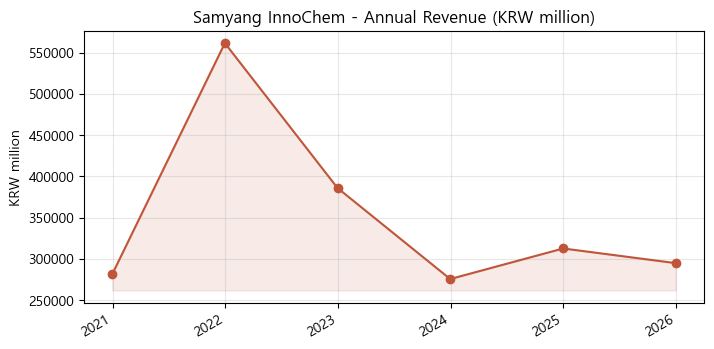

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(annual_df.index, annual_df["revenue"], marker="o", color="#C0553A")
ax.fill_between(annual_df.index, annual_df["revenue"], annual_df["revenue"].min() * 0.95, alpha=0.12, color="#C0553A")
ax.set_title("Samyang InnoChem - Annual Revenue (KRW million)")
ax.set_ylabel("KRW million")
ax.grid(alpha=0.3)
fig.autofmt_xdate()
plt.show()

## 2. DB에서 경제지표 로드

BPA 원료(벤젠/페놀/아세톤)는 석유화학 기반이라 유가·환율·수입물가 위주로 골랐다.

In [5]:
from sqlalchemy import create_engine
import os

engine = create_engine(os.environ["DATABASE_URL"], pool_pre_ping=True)

TARGETS = {
    "market_yfinance": ["WTI유가", "브렌트유", "원달러환율", "달러인덱스", "미국국채10년"],
    "import_price_index": ["한국", "미국"],
}

all_series = eda_utils.load_indicator_series(engine, TARGETS)
print(f"{len(all_series)}개 지표 시계열 로드")

7개 지표 시계열 로드


## 3. 연도별 지표 평균과 매출 정렬

In [6]:
aligned = eda_utils.align_indicators_to_periods(annual_df, "revenue", all_series)
aligned

,period_from,revenue,market_yfinance::WTI유가,market_yfinance::브렌트유,market_yfinance::원달러환율,market_yfinance::달러인덱스,market_yfinance::미국국채10년,import_price_index::한국,import_price_index::미국
period_to,,,,,,,,,
2020-12-31,2020-01-01,281418,42.036737,44.478421,1138.062856,92.514105,0.797916,100.306000,119.353928
2021-12-31,2021-01-01,561382,68.106032,70.953809,1143.850536,92.510793,1.440452,102.498333,124.266415
2022-12-31,2022-01-01,385876,94.331474,98.966335,1291.037695,104.049482,2.956837,107.715000,134.211207
2023-12-31,2023-01-01,275644,77.597120,82.190438,1305.279728,103.446600,3.965036,111.590000,139.735793
2024-12-31,2024-01-01,312647,75.758016,79.821310,1361.876494,104.198413,4.207135,114.180833,143.857335
2025-12-31,2025-01-01,294890,64.739524,68.101548,1419.838600,100.784881,4.286336,116.605000,147.642687


## 4. 레벨 기준 상관관계

표본이 6개뿐이라 `min_n`을 낮춰서 계산한다.

In [7]:
level_corr = eda_utils.corr_table(aligned, all_series, "revenue", min_n=5)
level_corr

,indicator,pearson,spearman,n
0,market_yfinance::원달러환율,-0.495523,-0.142857,6
1,import_price_index::한국,-0.455353,-0.142857,6
2,market_yfinance::달러인덱스,-0.445143,-0.085714,6
3,market_yfinance::미국국채10년,-0.443620,-0.142857,6
4,import_price_index::미국,-0.424053,-0.142857,6
5,market_yfinance::WTI유가,0.199095,0.200000,6
6,market_yfinance::브렌트유,0.177945,0.200000,6


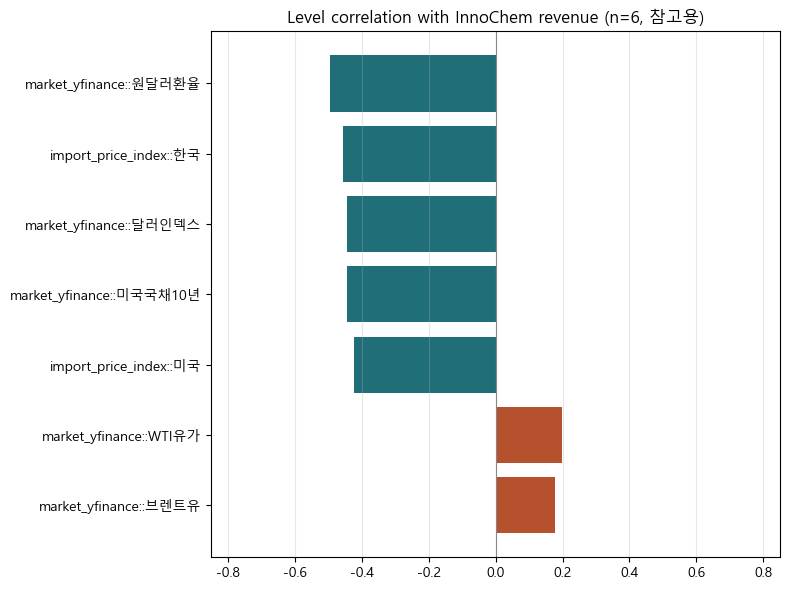

In [8]:
eda_utils.plot_top_correlations(level_corr, "Level correlation with InnoChem revenue (n=6, 참고용)")

## 5. 전기 대비 변화율(%) 기준 상관관계

In [9]:
pct = aligned.drop(columns=["period_from"]).pct_change().dropna(how="all")
pct_corr = eda_utils.corr_table(pct, all_series, "revenue", min_n=4)
pct_corr

,indicator,pearson,spearman,n
0,market_yfinance::WTI유가,0.647811,0.4,5
1,market_yfinance::브렌트유,0.622283,0.4,5
2,import_price_index::한국,-0.620512,-0.7,5
3,market_yfinance::원달러환율,-0.537357,-0.6,5
4,market_yfinance::달러인덱스,-0.331368,-0.2,5
5,import_price_index::미국,-0.306279,-0.6,5
6,market_yfinance::미국국채10년,0.169089,-0.3,5


## 6. 시차(Lag) 분석

연 단위이므로 lag는 0~1년만 본다 (표본이 6개뿐이라 그 이상은 비교 쌍이 너무 줄어든다).

> **표본 크기 재차 주의**: n=6 수준이라, 여기 나온 어떤 상관계수도 확정된 관계로
> 취급하면 안 된다.

In [10]:
level_df = aligned.drop(columns=["period_from"])
lag_df = eda_utils.lag_correlation_table(level_df, all_series, "revenue", max_lag=2, min_n=4)
lag_df

,indicator,best_lag,best_corr,L0,L1
0,market_yfinance::브렌트유,1,-0.956668,0.177945,-0.956668
1,market_yfinance::WTI유가,1,-0.954651,0.199095,-0.954651
2,import_price_index::미국,1,-0.847107,-0.424053,-0.847107
3,market_yfinance::달러인덱스,1,-0.842779,-0.445143,-0.842779
4,market_yfinance::미국국채10년,1,-0.841378,-0.443620,-0.841378
5,market_yfinance::원달러환율,1,-0.815053,-0.495523,-0.815053
6,import_price_index::한국,1,-0.807946,-0.455353,-0.807946


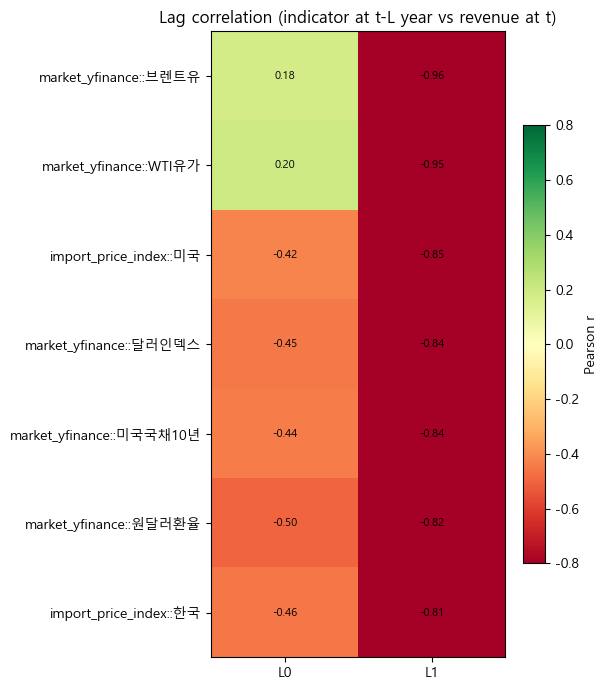

In [11]:
eda_utils.plot_lag_heatmap(lag_df, "Lag correlation (indicator at t-L year vs revenue at t)", max_lag=2, top_n=len(lag_df))

## 결론 및 한계

*(노트북을 실행한 뒤, 위 상관관계 표를 보고 이 셀에 실제 결론을 채워 넣을 것)*

- 표본이 6개 연도뿐이라 상관계수는 통계적으로 의미 있는 수준이 아니다 — 방향성 참고용.
- 2021년 매출이 전년 대비 2배 가까이 뛰었다가 2022~2023년에 다시 줄어드는 등 변동폭이
  커서, 유가·환율보다 BPA 자체의 스프레드(원료가 대비 판가) 사이클 영향이 더 클 수 있다
  — 이 노트북의 매크로 지표만으로는 온전히 설명되지 않을 가능성이 있다.